# MSA 575 Project: Analyzing Cross Functional Roles using a Position to Position Temporal Network

**Vinay Attri**  
**Dataset:** LinkedIn Connections (Exported CSV)

## 1. Import

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
import networkx.algorithms.community as nx_comm

from itertools import combinations
from networkx.algorithms import bipartite

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

## 2. Data Collection

In [ ]:
path = r"" #Updata the path here

df = pd.read_csv(os.path.join(path, 'Data.csv'))

print(f'Initial raw rows: {len(df)}')

df = df.dropna(subset=['Company', 'Position'])

df['Company'] = df['Company'].astype(str).str.lower().str.strip()
df['Position'] = df['Position'].astype(str).str.lower().str.strip()

df['Connected On'] = pd.to_datetime(df['Connected On'])
df['Quarter'] = df['Connected On'].dt.to_period('Q')

print(f'Rows after cleaning: {len(df)}')
print(f'Unique Companies: {df["Company"].nunique()}')
print(f'Unique Positions: {df["Position"].nunique()}')

display(df[['Company', 'Position', 'Quarter']].head())
print(df['Quarter'])

Initial raw rows: 1863
Rows after cleaning: 1736
Unique Companies: 1301
Unique Positions: 1122


,Company,Position,Quarter
0,"index super speciality hospital, indore",quality manager,2026Q2
1,tata capital,manager - pl - digital,2026Q2
2,"manning consulting, new delhi (india)",sourcing specialist,2026Q2
3,state university of new york at plattsburgh,international orientation leader,2026Q2
4,unitedhealth group,healthcare data analyst,2026Q2


0       2026Q2
1       2026Q2
2       2026Q2
3       2026Q2
4       2026Q2
         ...  
1858    2022Q3
1859    2022Q3
1860    2022Q3
1861    2022Q3
1862    2022Q3
Name: Quarter, Length: 1736, dtype: period[Q-DEC]


### Process

First, I loaded the LinkedIn CSV file and removed the rows where the company name or job title was missing because those records would not be useful for the network analysis.

Then, I changed all text into lowercase letters so that similar job titles like "Software Engineer" and "software engineer" are counted as the same.

After that, I created a new column called Quarter.

This column changes each connection date into a quarterly period such as Q1 2022, which will help me study how the network changes over time later.

## 3. Bipartite Projection (Building the network)

In [3]:
def build_graph(data):
    """Build a weighted position-to-position co-occurrence graph from a dataframe."""
    g = nx.Graph()
    grouped = data.groupby('Company')['Position'].unique()
    for company, positions in grouped.items():
        if len(positions) > 1:
            for pos1, pos2 in combinations(positions, 2):
                if g.has_edge(pos1, pos2):
                    g[pos1][pos2]['weight'] += 1
                else:
                    g.add_edge(pos1, pos2, weight=1)
    return g

# Build the global static graph using all data
G = build_graph(df)
G.remove_nodes_from(list(nx.isolates(G)))

print(f'Total Nodes (Job Titles): {G.number_of_nodes()}')
print(f'Total Edges (Shared Companies): {G.number_of_edges()}')

Total Nodes (Job Titles): 393
Total Edges (Shared Companies): 3302


## 4. Core Network Analysis

In [4]:
density = nx.density(G)
largest_cc = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(largest_cc)

avg_path_length = nx.average_shortest_path_length(G_giant)
global_clustering = nx.transitivity(G)
assortativity = nx.degree_assortativity_coefficient(G)

print(f'Network Density: {density:.4f}')
print(f'Size of Giant Component: {G_giant.number_of_nodes()} nodes')
print(f'Avg Shortest Path (Giant): {avg_path_length:.4f}')
print(f'Global Clustering Coefficient: {global_clustering:.4f}')
print(f'Degree Assortativity: {assortativity:.4f}')

if assortativity > 0:
    print('Positive assortativity: hub roles connect to other hubs (core periphery)')
else:
    print('Negative assortativity: hub roles bridge out to specialized low degree roles')

Network Density: 0.0429
Size of Giant Component: 225 nodes
Avg Shortest Path (Giant): 2.6100
Global Clustering Coefficient: 0.9028
Degree Assortativity: 0.6873
Positive assortativity: hub roles connect to other hubs (core periphery)


### What do these numbers mean?

Network Density: 0.0429
The density of the network is very low, which means only a small number of all possible connections actually exist between job titles.
This is expected because not every role appears with every other role in the same company.
It shows that the professional network is sparse, with roles connecting only to specific related roles.

Size of Giant Component: 225 nodes
The largest connected part of the network contains 225 job titles.
This means most roles belong to one main group where they can be reached through shared company connections.
It suggests that the network is mostly connected rather than divided into many separate groups.

Average Shortest Path: 2.6100
On average, any two job titles in the largest network group are only about 2.6 steps apart.
This means one role can reach another through only a few intermediate roles.
It shows that the network is highly compact even though it contains many nodes.

Global Clustering Coefficient: 0.9028
This value is very high, meaning connected job titles often form tightly linked groups.
If one role is connected to two other roles, those roles are also very likely connected to each other.
This suggests that related roles commonly appear together inside the same companies.

Degree Assortativity: 0.6873
The positive assortativity value shows that highly connected roles usually connect to other highly connected roles.
This means central or common roles tend to form a strong core in the network.
It indicates a core-periphery structure, where major roles are closely linked while smaller roles connect around them.

## 5. Centrality Analysis (Finding the Hubs and Bridges)

--- Top 5 Job Titles by Betweenness Centrality (The Bridges) ---


,Betweenness Centrality
data analyst,0.109717
manager,0.039074
business analyst,0.036367
pharmacist,0.027269
assistant manager,0.025620



--- Top 5 Job Titles by Degree Centrality (The Hubs) ---


,Degree Centrality
manager,0.234694
human resources specialist,0.211735
senior executive,0.209184
project manager,0.209184
deputy manager,0.209184


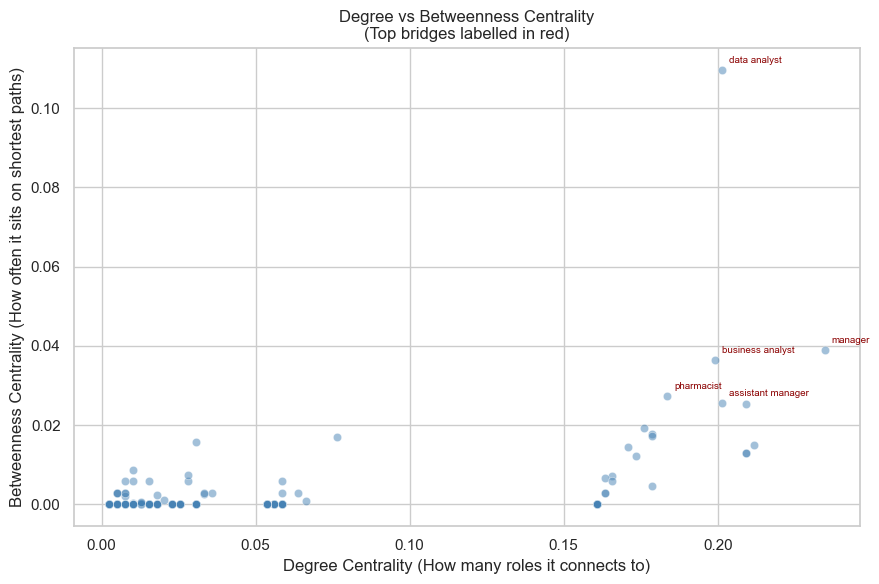

In [5]:
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    'Degree Centrality': pd.Series(degree_cent),
    'Betweenness Centrality': pd.Series(betweenness_cent)
})

print('--- Top 5 Job Titles by Betweenness Centrality (The Bridges) ---')
display(
    centrality_df[['Betweenness Centrality']]
    .sort_values(by='Betweenness Centrality', ascending=False)
    .head(5)
)

print('\n--- Top 5 Job Titles by Degree Centrality (The Hubs) ---')
display(
    centrality_df[['Degree Centrality']]
    .sort_values(by='Degree Centrality', ascending=False)
    .head(5)
)

# Scatter plot unchanged — still uses both columns correctly
plt.figure(figsize=(9, 6))
plt.scatter(centrality_df['Degree Centrality'], centrality_df['Betweenness Centrality'],
            alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)

top5 = centrality_df.sort_values('Betweenness Centrality', ascending=False).head(5)
for role, row in top5.iterrows():
    plt.annotate(role, (row['Degree Centrality'], row['Betweenness Centrality']),
                 textcoords='offset points', xytext=(5, 5), fontsize=7, color='darkred')

plt.title('Degree vs Betweenness Centrality\n(Top bridges labelled in red)')
plt.xlabel('Degree Centrality (How many roles it connects to)')
plt.ylabel('Betweenness Centrality (How often it sits on shortest paths)')
plt.tight_layout()
plt.show()

### Interpretation of Degree and Betweenness Centrality

These results show that some job titles are important in the network for different reasons. 

High Degree Centrality = Hub Roles
Roles with high degree centrality are connected to many other roles.
For example, manager has the highest degree centrality (0.2347), showing it appears with many different job titles across companies.
This makes it a major hub role in the network.

High Betweenness Centrality = Bridge Roles
Roles with high betweenness centrality connect different parts of the network.
The role data analyst has the highest betweenness (0.1097), meaning it acts as a strong link between different job groups.
This makes it the most important bridge role in the network.

Overall Meaning
The scatter plot shows that manager is the strongest hub, while data analyst is the strongest bridge.
This means some roles are important because they connect to many others, while others are important because they connect different groups together.

## 6. Community Detection (Louvain Method)

In [6]:
communities = nx_comm.louvain_communities(G, weight='weight', seed=42)
print(f'Number of communities detected: {len(communities)}\n')

sorted_communities = sorted(communities, key=len, reverse=True)

print('Top 5 largest communities and their most connected roles:\n')
for i, comm in enumerate(sorted_communities[:5]):
    roles = list(comm)
    roles_sorted = sorted(roles, key=lambda x: degree_cent[x], reverse=True)
    print(f'Community {i+1} | Size: {len(comm)} roles')
    print(f'  Top roles: {roles_sorted[:6]}')
    print()

Number of communities detected: 68

Top 5 largest communities and their most connected roles:

Community 1 | Size: 69 roles
  Top roles: ['senior executive', 'assistant manager', 'business analyst', 'pharmacist', 'senior business analyst', 'executive pharmacist']

Community 2 | Size: 55 roles
  Top roles: ['manager', 'human resources specialist', 'project manager', 'deputy manager', 'data analyst', 'it analyst']

Community 3 | Size: 38 roles
  Top roles: ['analyst', 'data scientist', 'accounts receivable analyst', 'talent acquisition executive', 'program manager, global tax & legal chief technology office', 'analyst tax natioal office']

Community 4 | Size: 27 roles
  Top roles: ['assistant professor', 'data analytics fellow', 'student', 'director, global education office (geo)', 'its student technician', 'research fellowship']

Community 5 | Size: 22 roles
  Top roles: ['clinical adjunct', 'vice president of strategic initiatives and workforce development', 'director of marketing and 

### Interpretation of Community Detection

The community detection algorithm found 68 communities, which means the network contains many different professional groups.
Each community represents a set of job titles that are more closely connected to each other than to the rest of the network.

For example, Community 1 includes roles like senior executive, business analyst, pharmacist, and senior data analyst, showing a mix of leadership and analytical roles.
Community 2 contains roles such as manager, project manager, data analyst, and IT analyst, which suggests a management and technical cluster.
Community 3 includes analyst, data scientist, and python/power bi analyst, showing a stronger data-focused group.

Some smaller communities also reflect specific sectors.
For example, Community 4 includes academic roles like assistant professor, while Community 5 contains roles related to education administration and admissions.

Overall, these communities show that job titles naturally form groups based on similar industries or professional functions within the network.

## 7. Degree Distribution

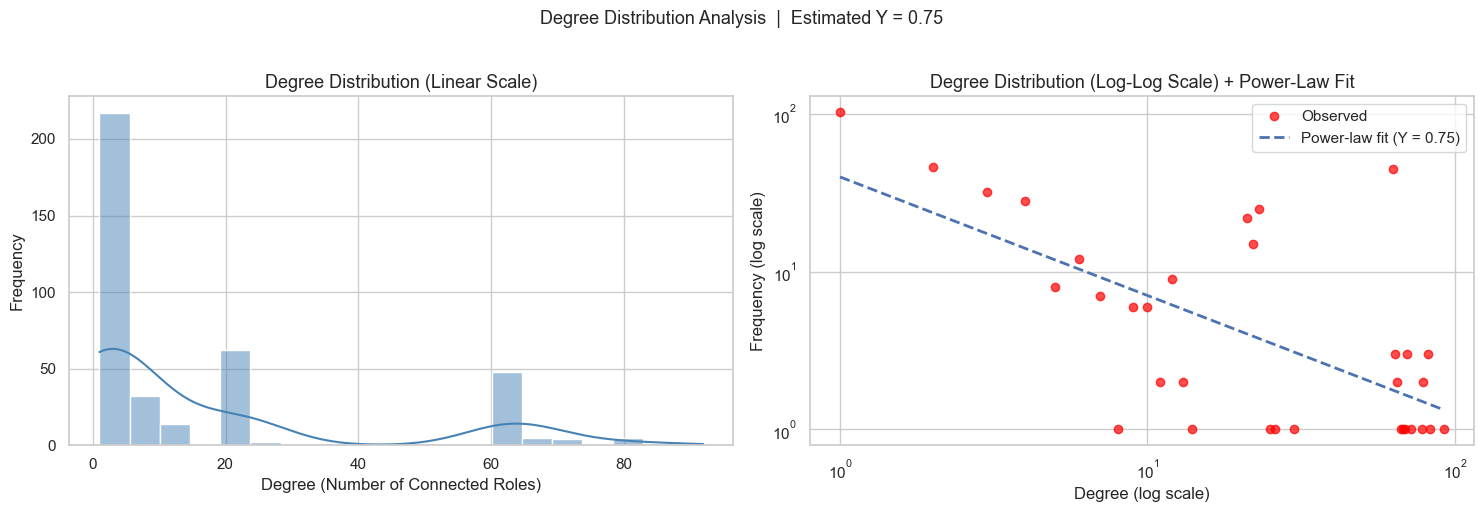

Estimated Power-Law Exponent (Y): 0.7523
-> Y < 2: very heavy tail - extreme hub dominance.


In [7]:
degrees = [degree for node, degree in G.degree()]
degree_counts = pd.Series(degrees).value_counts().sort_index()

# Power-law slope via linear regression on log-log data
log_k = np.log10(degree_counts.index.values.astype(float))
log_pk = np.log10(degree_counts.values.astype(float))
slope, intercept = np.polyfit(log_k, log_pk, 1)
fit_line = np.poly1d([slope, intercept])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: standard histogram
sns.histplot(degrees, bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Degree Distribution (Linear Scale)', fontsize=13)
axes[0].set_xlabel('Degree (Number of Connected Roles)')
axes[0].set_ylabel('Frequency')

# Right: log-log with fitted line
axes[1].loglog(degree_counts.index, degree_counts.values,
               marker='o', linestyle='none', color='red', alpha=0.7, label='Observed')
k_range = np.logspace(np.log10(degree_counts.index.min()),
                       np.log10(degree_counts.index.max()), 100)
axes[1].loglog(k_range, 10**fit_line(np.log10(k_range)),
               'b--', linewidth=2, label=f'Power-law fit (Y = {abs(slope):.2f})')
axes[1].set_title('Degree Distribution (Log-Log Scale) + Power-Law Fit', fontsize=13)
axes[1].set_xlabel('Degree (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].legend()

plt.suptitle(f'Degree Distribution Analysis  |  Estimated Y = {abs(slope):.2f}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Estimated Power-Law Exponent (Y): {abs(slope):.4f}')
if 2.0 <= abs(slope) <= 3.0:
    print('-> Y is between 2 and 3: consistent with a scale-free network (typical of real-world networks).')
elif abs(slope) < 2.0:
    print('-> Y < 2: very heavy tail - extreme hub dominance.')
else:
    print('-> Y > 3: lighter tail i less hub-dominated, closer to random.')

### Interpretation of Degree Distribution

The estimated power-law exponent is 0.7523, which is less than 2.
This means the network has a very heavy-tailed degree distribution, where a small number of job titles have a very large number of connections.

The left histogram shows that most job titles have only a few connections, while only a few roles have very high degree values.
This creates a right-skewed distribution, which suggests that some roles are much more central than others.

The log-log plot on the right also supports this pattern.
Although the points do not perfectly follow the fitted line, the overall trend shows that the network is strongly influenced by a few highly connected hub roles.

Overall, the result suggests that the professional network is hub-dominated, where a small number of important roles connect a large part of the network.

## 8. Theoretical Model Comparison (ER and BA Models)

In [8]:
N = G.number_of_nodes()
L = G.number_of_edges()

p = (2 * L) / (N * (N - 1))
ER_graph = nx.erdos_renyi_graph(n=N, p=p, seed=42)

m = max(1, int(L / N))
BA_graph = nx.barabasi_albert_graph(n=N, m=m, seed=42)

ER_giant = ER_graph.subgraph(max(nx.connected_components(ER_graph), key=len))
BA_giant = BA_graph.subgraph(max(nx.connected_components(BA_graph), key=len))

print('='*60)
print(f'{'Metric':<35} {'Real':>8} {'ER':>8} {'BA':>8}')
print('='*60)
print(f'{'Avg Shortest Path Length':<35} {nx.average_shortest_path_length(G_giant):>8.4f} {nx.average_shortest_path_length(ER_giant):>8.4f} {nx.average_shortest_path_length(BA_giant):>8.4f}')
print(f'{'Average Clustering Coefficient':<35} {nx.average_clustering(G):>8.4f} {nx.average_clustering(ER_graph):>8.4f} {nx.average_clustering(BA_graph):>8.4f}')
print(f'{'Network Density':<35} {nx.density(G):>8.4f} {nx.density(ER_graph):>8.4f} {nx.density(BA_graph):>8.4f}')
print('='*60)

Metric                                  Real       ER       BA
Avg Shortest Path Length              2.6100   2.4298   2.4033
Average Clustering Coefficient        0.6867   0.0416   0.1032
Network Density                       0.0429   0.0424   0.0400


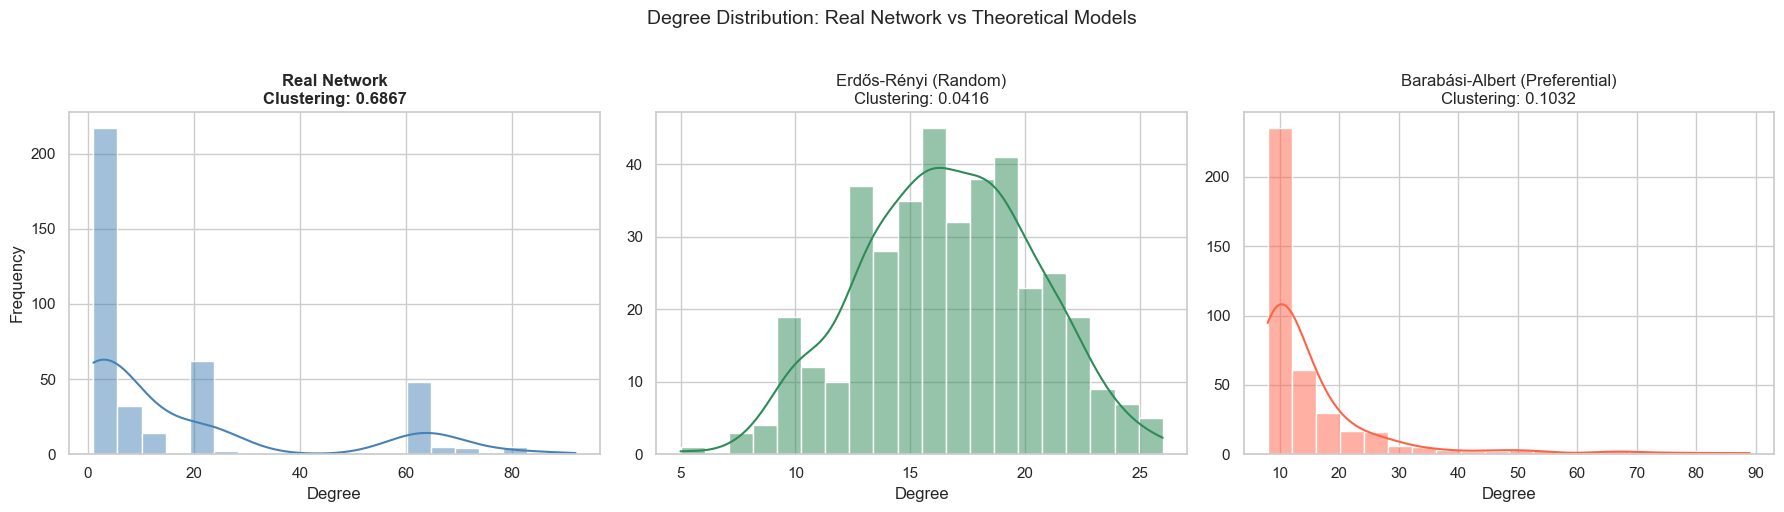

In [9]:
#  Degree Distribution Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

real_degrees = [d for n, d in G.degree()]
er_degrees   = [d for n, d in ER_graph.degree()]
ba_degrees   = [d for n, d in BA_graph.degree()]

real_clust = nx.average_clustering(G)
er_clust   = nx.average_clustering(ER_graph)
ba_clust   = nx.average_clustering(BA_graph)

sns.histplot(real_degrees, bins=20, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title(f'Real Network\nClustering: {real_clust:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('Frequency')

sns.histplot(er_degrees, bins=20, ax=axes[1], color='seagreen', kde=True)
axes[1].set_title(f'Erdős-Rényi (Random)\nClustering: {er_clust:.4f}', fontsize=12)
axes[1].set_xlabel('Degree'); axes[1].set_ylabel('')

sns.histplot(ba_degrees, bins=20, ax=axes[2], color='tomato', kde=True)
axes[2].set_title(f'Barabási-Albert (Preferential)\nClustering: {ba_clust:.4f}', fontsize=12)
axes[2].set_xlabel('Degree'); axes[2].set_ylabel('')

plt.suptitle('Degree Distribution: Real Network vs Theoretical Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

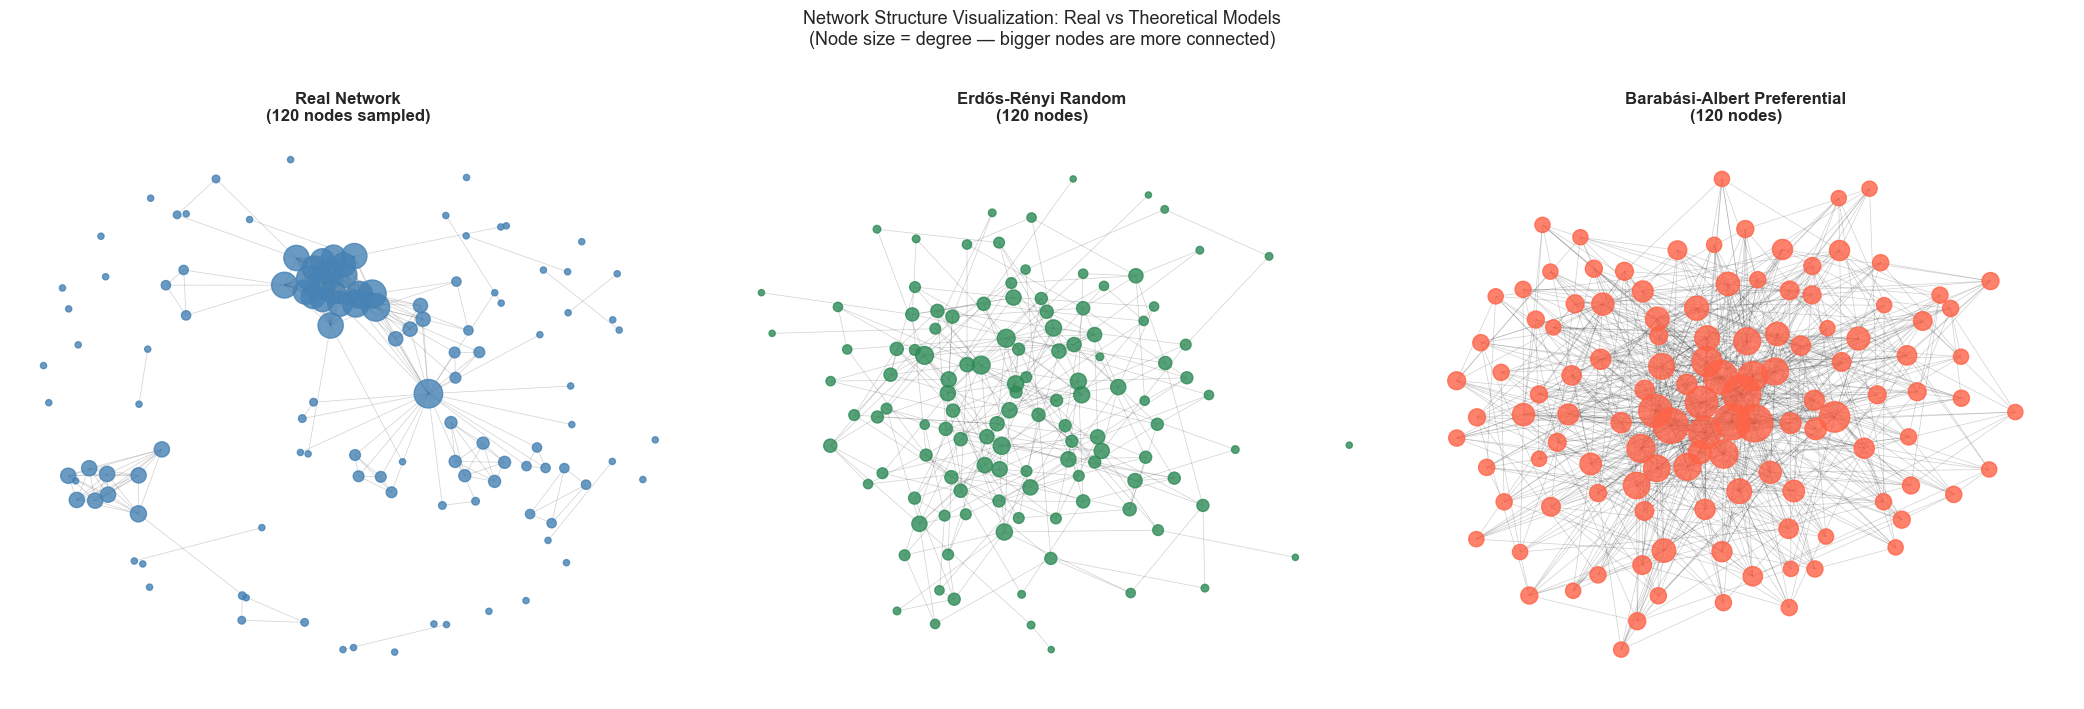

In [10]:
# Network Structure Visualization (sampled for clarity)

# We sample a subgraph of up to 120 nodes for visual clarity
np.random.seed(42)
sample_size = min(120, G.number_of_nodes())
sampled_nodes = np.random.choice(list(G.nodes()), size=sample_size, replace=False)
G_vis = G.subgraph(sampled_nodes)

# Sample same number of nodes from ER and BA
ER_vis = ER_graph.subgraph(list(ER_graph.nodes())[:sample_size])
BA_vis = BA_graph.subgraph(list(BA_graph.nodes())[:sample_size])

def draw_network(ax, graph, title, color, pos=None):
    if pos is None:
        pos = nx.spring_layout(graph, seed=42, k=0.4)
    degrees = dict(graph.degree())
    node_sizes = [max(20, degrees[n] * 15) for n in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=node_sizes,
                           node_color=color, alpha=0.8)
    nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.2, width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    return pos

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
draw_network(axes[0], G_vis,  f'Real Network\n({sample_size} nodes sampled)', 'steelblue')
draw_network(axes[1], ER_vis, f'Erdős-Rényi Random\n({sample_size} nodes)',   'seagreen')
draw_network(axes[2], BA_vis, f'Barabási-Albert Preferential\n({sample_size} nodes)', 'tomato')

plt.suptitle('Network Structure Visualization: Real vs Theoretical Models\n'
             '(Node size = degree — bigger nodes are more connected)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation of Real Network vs Theoretical Models

The comparison shows that the real network is very different from a random network.
The real network has a clustering coefficient of 0.6867, which is much higher than both the ER model (0.0416) and the BA model (0.1032).
This means job titles form much stronger local groups in the real network.

At the same time, the average shortest path in the real network is 2.61, which is close to the ER (2.43) and BA (2.40) models.
This shows that even though the network has strong clusters, roles can still be reached in only a few steps.

The degree distribution plots also support this.
The real network shows a more uneven pattern with some highly connected roles, while the ER model looks more uniform and the BA model shows hub formation but weaker clustering.

Overall, these results suggest that the professional network has a small-world structure, where job titles form tight groups while still remaining closely connected across the network.

## 9. Temporal Network Evolution

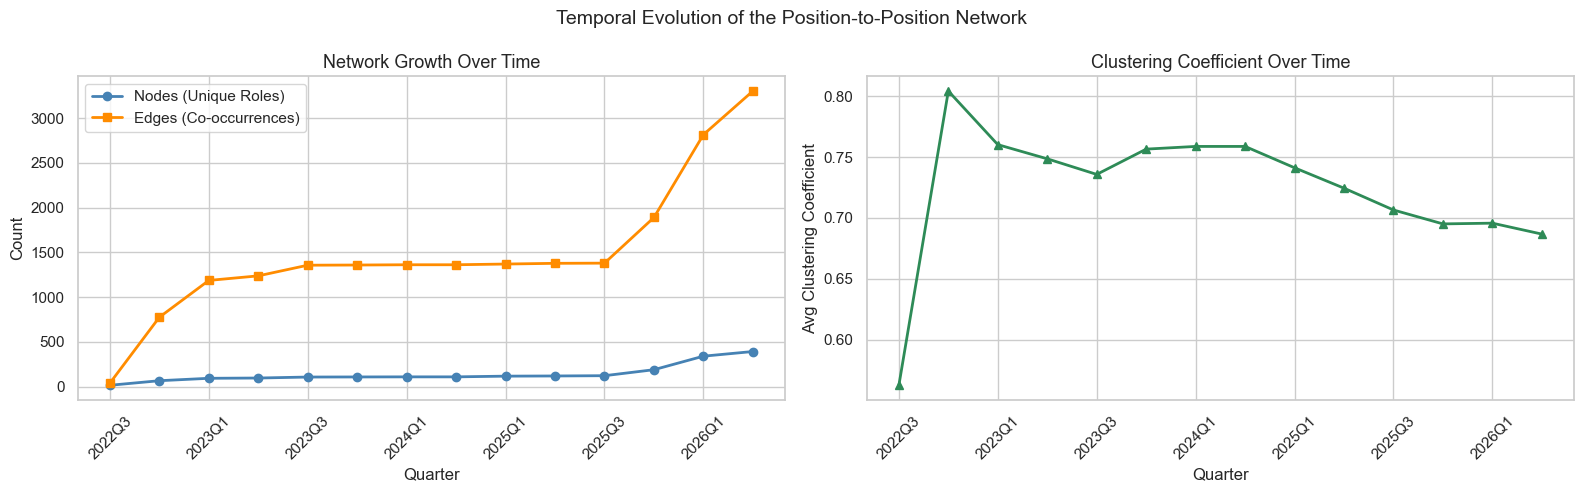

In [11]:
quarters = sorted(df['Quarter'].dropna().unique())

temporal_data = []

for q in quarters:
    df_q = df[df['Quarter'] <= q]
    G_q = build_graph(df_q)
    G_q.remove_nodes_from(list(nx.isolates(G_q)))

    if G_q.number_of_nodes() > 10:
        temporal_data.append({
            'Quarter': str(q),
            'Nodes': G_q.number_of_nodes(),
            'Edges': G_q.number_of_edges(),
            'Clustering': nx.average_clustering(G_q)
        })

temp_df = pd.DataFrame(temporal_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(temp_df['Quarter'], temp_df['Nodes'],  marker='o', label='Nodes (Unique Roles)',    color='steelblue', linewidth=2)
axes[0].plot(temp_df['Quarter'], temp_df['Edges'],  marker='s', label='Edges (Co-occurrences)',  color='darkorange', linewidth=2)
axes[0].set_title('Network Growth Over Time', fontsize=13)
axes[0].set_xticks(range(0, len(temp_df), max(1, len(temp_df)//6)))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].set_xlabel('Quarter'); axes[0].set_ylabel('Count')

axes[1].plot(temp_df['Quarter'], temp_df['Clustering'], marker='^', color='seagreen', linewidth=2)
axes[1].set_title('Clustering Coefficient Over Time', fontsize=13)
axes[1].set_xticks(range(0, len(temp_df), max(1, len(temp_df)//6)))
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Quarter'); axes[1].set_ylabel('Avg Clustering Coefficient')

plt.suptitle('Temporal Evolution of the Position-to-Position Network', fontsize=14)
plt.tight_layout()
plt.show()

###  What the growth curves tell us

Network Growth & Densification: 
My network is densifying rapidly. The left graph shows that connections (the orange line) are growing much faster than unique roles (the blue line). The massive spike in late 2025 likely reflects a major milestone such as diving deeper into my Data Analytics program or expanding my internship outreach bringing a surge of interconnected people into my network at once.

Clustering & Career Breadth: The right graph shows my average clustering coefficient trending downward since late 2022. While my network is dense, this falling clustering is the classic signature of increasing career breadth. Instead of staying within one isolated professional bubble, my newer connections are pulling from different domains, allowing me to bridge gaps between industries rather than just filling them in.

Takeaway
Overall, the data shows I am building a highly connected network without getting trapped in a single echo chamber. As my career grows, I am successfully expanding my reach across diverse, non-overlapping professional spheres.